<a href="https://colab.research.google.com/github/parvx07/Unibiased_AI_Decision/blob/main/Bias_Analysis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic Bias Analysis
### Unbiased AI Decision
Run each cell top to bottom. All steps are explained inline.

## Step 1 — Install libraries

In [ ]:
!pip install fairlearn google-genai pandas matplotlib seaborn scikit-learn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 32.7 MB/s eta 0:00:00


## Step 2 — Upload and load your dataset
Run this cell. A file picker will appear — upload your CSV file (e.g., `compas-scores-raw.csv` or `HR-Employee-Attrition.csv`).


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(filename)

print(f'Loaded {len(df_raw)} rows and {len(df_raw.columns)} columns')
df_raw.head(3)

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv
Loaded 1470 rows and 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


## Step 3 — Dynamic Configuration & AI Model Training
Instead of hardcoding, tell the script which columns to look at. Then, we will train a Random Forest model so we can audit the software's *predictions* rather than just the historical data.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import ipywidgets as widgets
from IPython.display import display

print("Available columns in your dataset:")
print(list(df_raw.columns))
print("-" * 50)


target_dropdown = widgets.Dropdown(
    options=df_raw.columns.tolist(),
    value='Attrition',
    description='Outcome col:'
)
sensitive_dropdown = widgets.Dropdown(
    options=df_raw.columns.tolist(),
    value='Gender',
    description='Sensitive col:'
)
display(target_dropdown, sensitive_dropdown)
print("Select your columns above, then run the NEXT cell.")

# ── 2. Preprocessing
# Drop rows with missing values in our key columns
df_clean = df_raw.dropna(subset=[target_col, sensitive_col]).copy()

# Fix inconsistent ethnicity labels in COMPAS dataset
if sensitive_col == 'Ethnic_Code_Text':
    df_clean['Ethnic_Code_Text'] = df_clean['Ethnic_Code_Text'].replace({
        'African-Am':  'African-American',
        'Oriental':    'Asian'
    })

# Convert target to 0s and 1s if it is text (like 'Yes'/'No' or 'High'/'Low')
le_target = LabelEncoder()
df_clean['target_encoded'] = le_target.fit_transform(df_clean[target_col])

# ── 3. Smart Feature Selection
# Drop the target and sensitive columns from training
X = df_clean.drop(columns=[target_col, 'target_encoded', sensitive_col])

# RAM SAVER: Drop high-cardinality text columns (like IDs, Names, Dates)
cols_to_drop = []
for col in X.columns:
    # If it's a text column and has more than 20 unique values, it's probably an ID or Date
    if X[col].dtype == 'object' and X[col].nunique() > 20:
        cols_to_drop.append(col)

print(f"Dropping high-cardinality/ID columns to save RAM: {cols_to_drop}")
X = X.drop(columns=cols_to_drop)

# Now it is safe to convert the remaining categorical columns to numbers
X = pd.get_dummies(X, drop_first=True)

# Fill any missing number values with 0 just to be safe
X = X.fillna(0)

y = df_clean['target_encoded']
sensitive_features = df_clean[sensitive_col]

# Split into training and testing data
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive_features, test_size=0.3, random_state=42
)

print("\nTraining AI Model...")
clf = RandomForestClassifier(random_state=42, n_estimators=50)
clf.fit(X_train, y_train)

# Generate predictions to audit
y_pred = clf.predict(X_test)
print(f"Model trained! Testing on {len(X_test)} records.")

Available columns in your dataset:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
--------------------------------------------------


TraitError: Invalid selection: value not found

In [ ]:
target_col    = target_dropdown.value
sensitive_col = sensitive_dropdown.value
print(f"Outcome column:   {target_col}")
print(f"Sensitive column: {sensitive_col}")

Outcome column:   ScoreText
Sensitive column: Ethnic_Code_Text


## Step 4 — Exploratory analysis
Before computing bias metrics, visualise how the AI's predictions are distributed across the sensitive group you selected.

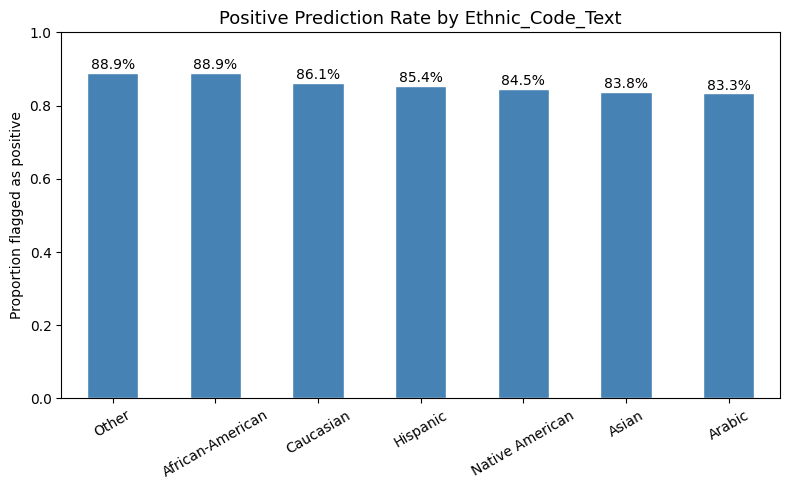

Chart saved as bias_overview.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary dataframe of the test results
test_results = pd.DataFrame({
    sensitive_col: s_test,
    'Predicted_Positive': y_pred
})

# Calculate the prediction rate per group
rates = test_results.groupby(sensitive_col)['Predicted_Positive'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
rates.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'Positive Prediction Rate by {sensitive_col}', fontsize=13)
plt.ylabel('Proportion flagged as positive')
plt.xlabel('')
plt.xticks(rotation=30)
plt.ylim(0, 1)

for bar, val in zip(plt.gca().patches, rates):
    plt.gca().text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('bias_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as bias_overview.png')

## Step 5 — Compute bias metrics with Fairlearn
`demographic_parity_difference` = gap in prediction rates between groups.

`equalized_odds_difference` = gap in error rates (false positives/negatives) between groups.
Both: 0 = perfectly fair, higher = more biased.

In [ ]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame, selection_rate

# ── Calculate core metrics
dp_gap = demographic_parity_difference(y_test, y_pred, sensitive_features=s_test)
eo_gap = equalized_odds_difference(y_test, y_pred, sensitive_features=s_test)

# ── Per-group selection rates
mf_selection = MetricFrame(
    metrics={'selection_rate': selection_rate},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test
)
group_rates = mf_selection.by_group['selection_rate'].sort_values(ascending=False)

print('=' * 50)
print('BIAS METRICS SUMMARY')
print('=' * 50)
print(f'Demographic parity gap: {dp_gap:.4f}')
print(f'Equalized odds gap:     {eo_gap:.4f}')
print(f'\nPrediction rate per {sensitive_col} group:')
print(group_rates.to_string())

BIAS METRICS SUMMARY
Demographic parity gap: 0.0557
Equalized odds gap:     0.2368

Prediction rate per Ethnic_Code_Text group:
Ethnic_Code_Text
Other               0.889032
African-American    0.888999
Caucasian           0.861341
Hispanic            0.853753
Native American     0.845070
Asian               0.838095
Arabic              0.833333


## Step 6 — Gemini AI explanation
Make sure your Gemini API key is saved in the Colab 'Secrets' tab (the Key icon on the left) under the name `GEMINI_API_KEY`.

In [ ]:
from google import genai
from google.colab import userdata

# Pull your API key safely from Colab Secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)

# Format the group breakdown for the prompt
group_lines = "\n".join([f"  - {k}: {v:.1%} flagged positive" for k, v in group_rates.items()])

prompt = f"""
You are a fairness expert helping a non-technical administrator understand an AI bias audit report.

An automated decision tool was trained and audited for bias. Here are the findings based on the sensitive attribute: {sensitive_col}.

Demographic Parity Gap: {dp_gap:.4f} (0 = perfectly fair, higher = more biased)
Equalized Odds Gap: {eo_gap:.4f} (0 = perfectly fair, higher = more biased)

Breakdown of selection rates by {sensitive_col}:
{group_lines}

Please do the following:
1. In 3 simple, jargon-free sentences, explain what these numbers mean for real people.
2. State clearly which group is most disadvantaged and by how much.
3. Give 2 concrete steps the organization could take to reduce this bias.

Write as if explaining to someone with no data science background.
"""

# Generate using the current active model
response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt
)

print("GEMINI AI EXPLANATION")
print("=" * 50)
print(response.text)

GEMINI AI EXPLANATION
Here's an explanation of your AI bias audit report:

1.  **What these numbers mean for real people:**
    *   This report shows our automated tool isn't flagging people from every ethnic background at the same rate, even if the differences aren't huge.
    *   More importantly, the "Equalized Odds Gap" tells us the tool might be making significantly different kinds of errors, or being less accurate, for some groups compared to others.
    *   This means people from certain backgrounds could be unfairly missed for opportunities or wrongly flagged for scrutiny more often than others, simply due to their ethnicity.

2.  **Most disadvantaged group and by how much:**
    The group most disadvantaged by this tool is the **Arabic** group. They are flagged positive 83.3% of the time, which is 5.6 percentage points less often than the groups with the highest flagging rates (Other and African-American, both at 88.9%).

3.  **Concrete steps to reduce this bias:**
    1.  **R

## Step 7 — Save results for your web app
Export the metrics and AI explanation as JSON — your React frontend will read this.

In [ ]:
import json

# ── Build the results object your frontend will consume
results = {
    'dataset_rows': len(df_clean),
    'analyzed_attribute': sensitive_col,
    'bias_metrics': {
        'demographic_parity_gap': round(float(dp_gap), 4),
        'equalized_odds_gap': round(float(eo_gap), 4),
        'per_group_selection_rates': {str(k): round(float(v), 4) for k, v in group_rates.items()}
    },
    'ai_explanation': response.text
}

with open('dynamic_bias_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Saved: dynamic_bias_results.json')
print('\nPreview of JSON payload:')
print(json.dumps(results, indent=2))

Saved: dynamic_bias_results.json

Preview of JSON payload:
{
  "dataset_rows": 60843,
  "analyzed_attribute": "Ethnic_Code_Text",
  "bias_metrics": {
    "demographic_parity_gap": 0.0557,
    "equalized_odds_gap": 0.2368,
    "per_group_selection_rates": {
      "Other": 0.889,
      "African-American": 0.889,
      "Caucasian": 0.8613,
      "Hispanic": 0.8538,
      "Native American": 0.8451,
      "Asian": 0.8381,
      "Arabic": 0.8333
    }
  },
  "ai_explanation": "Here's an explanation of your AI bias audit report:\n\n1.  **What these numbers mean for real people:**\n    *   This report shows our automated tool isn't flagging people from every ethnic background at the same rate, even if the differences aren't huge.\n    *   More importantly, the \"Equalized Odds Gap\" tells us the tool might be making significantly different kinds of errors, or being less accurate, for some groups compared to others.\n    *   This means people from certain backgrounds could be unfairly missed fo

## What to do next
1. Take `dynamic_bias_results.json` — this is what your backend will return to your React frontend.
2. Take `bias_overview.png` — use this dynamic chart in your project pitch deck.
3. Because Step 3 uses `input()`, you can now upload the **COMPAS dataset** OR your friend's **HR Attrition dataset** without changing a single line of code!